# Process 1 – Sterilization Simulation Explorer

Use this notebook to inspect and correct the simulation output.
Re-run `generate_process_1.py` after tuning parameters in that file, then re-run this notebook.

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import pm4py
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery
from pm4py.visualization.dfg import visualizer as dfg_vis

DATA_DIR = Path('..') / '..' / 'data' / 'gold' / 'experiment_1' / 'process_1' / 'datasets'

df_event_log      = pd.read_parquet(DATA_DIR / 'df_event_log.parquet')
df_expanded       = pd.read_parquet(DATA_DIR / 'df_expanded.parquet')
df_production_plan = pd.read_parquet(DATA_DIR / 'df_production_plan.parquet')

print('Event log:       ', df_event_log.shape)
print('Expanded:        ', df_expanded.shape)
print('Production plan: ', df_production_plan.shape)

Event log:        (5621, 10)
Expanded:         (36268, 18)
Production plan:  (300, 5)


## 1. Event log overview

In [ ]:
print('Columns:', df_event_log.dtypes.to_dict())
df_event_log.head(14)

Columns: {'case_id': dtype('O'), 'activity': dtype('O'), 'timestamp_start': dtype('<M8[ns]'), 'timestamp_end': dtype('<M8[ns]'), 'higher_level_activity': dtype('O'), 'station': dtype('O'), 'object_type': dtype('O'), 'object': dtype('O'), 'object_attributes': dtype('O'), 'autoclave_cycle_id': dtype('O')}


,case_id,activity,timestamp_start,timestamp_end,higher_level_activity,station,object_type,object,object_attributes,autoclave_cycle_id
0,batch_001,water_supply_prepare,2024-01-15 00:00:00.000000,2024-01-15 00:00:05.559925,sterilization_process,Water_supply,sterilization_line,water_supply,"{'idle_min': 0.0, 'recipe': 'standard', 'volum...",None
1,batch_001,water_supply_working,2024-01-15 00:00:06.559925,2024-01-15 00:01:11.977309,sterilization_process,Water_supply,sterilization_line,water_supply,"{'idle_min': 0.0, 'recipe': 'standard', 'volum...",None
2,batch_001,destillation_preparation,2024-01-15 00:01:12.977309,2024-01-15 00:03:48.915022,sterilization_process,Destillation,sterilization_line,destillation,"{'idle_min': 1.2, 'recipe': 'standard', 'volum...",None
3,batch_001,destillation_production,2024-01-15 00:03:49.915022,2024-01-15 00:27:08.781001,sterilization_process,Destillation,sterilization_line,destillation,"{'idle_min': 1.2, 'recipe': 'standard', 'volum...",None
4,batch_001,destillation_emptying,2024-01-15 00:27:09.781001,2024-01-15 00:30:48.661422,sterilization_process,Destillation,sterilization_line,destillation,"{'idle_min': 1.2, 'recipe': 'standard', 'volum...",None
5,batch_001,bottling_prepare,2024-01-15 00:30:49.661422,2024-01-15 00:30:55.221347,sterilization_process,Bottling,sterilization_line,bottling,"{'idle_min': 30.8, 'recipe': 'standard', 'volu...",None
6,batch_001,bottling_working,2024-01-15 00:30:56.221347,2024-01-15 00:31:35.110787,sterilization_process,Bottling,sterilization_line,bottling,"{'idle_min': 30.8, 'recipe': 'standard', 'volu...",None
7,batch_001,bottling_cool,2024-01-15 00:31:36.110787,2024-01-15 00:31:41.670712,sterilization_process,Bottling,sterilization_line,bottling,"{'idle_min': 30.8, 'recipe': 'standard', 'volu...",None
8,batch_001,autoclaving_2_prepare,2024-01-15 00:31:42.670712,2024-01-15 00:33:45.376091,sterilization_process,Autoclaving,sterilization_line,autoclaving_2,"{'idle_min': 31.7, 'recipe': 'standard', 'volu...",None
9,batch_001,autoclaving_2_heat,2024-01-15 00:33:46.376091,2024-01-15 00:49:32.376091,sterilization_process,Autoclaving,sterilization_line,autoclaving_2,"{'idle_min': 31.7, 'recipe': 'standard', 'volu...",ac_1


In [ ]:
# Activity counts per station
(
    df_event_log
    .groupby(['station', 'activity'])
    .size()
    .rename('count')
    .reset_index()
    .sort_values(['station', 'activity'])
)

,station,activity,count
0,Autoclaving,autoclaving_1_cool,89
1,Autoclaving,autoclaving_1_heat,89
2,Autoclaving,autoclaving_1_hold,89
3,Autoclaving,autoclaving_1_prepare,89
4,Autoclaving,autoclaving_2_cool,152
5,Autoclaving,autoclaving_2_heat,152
6,Autoclaving,autoclaving_2_hold,152
7,Autoclaving,autoclaving_2_prepare,152
8,Autoclaving,autoclaving_3_cool,95
9,Autoclaving,autoclaving_3_heat,95


## 2. pm4py Directly-Follows Graph (DFG)

### 2a. Activity-level DFG

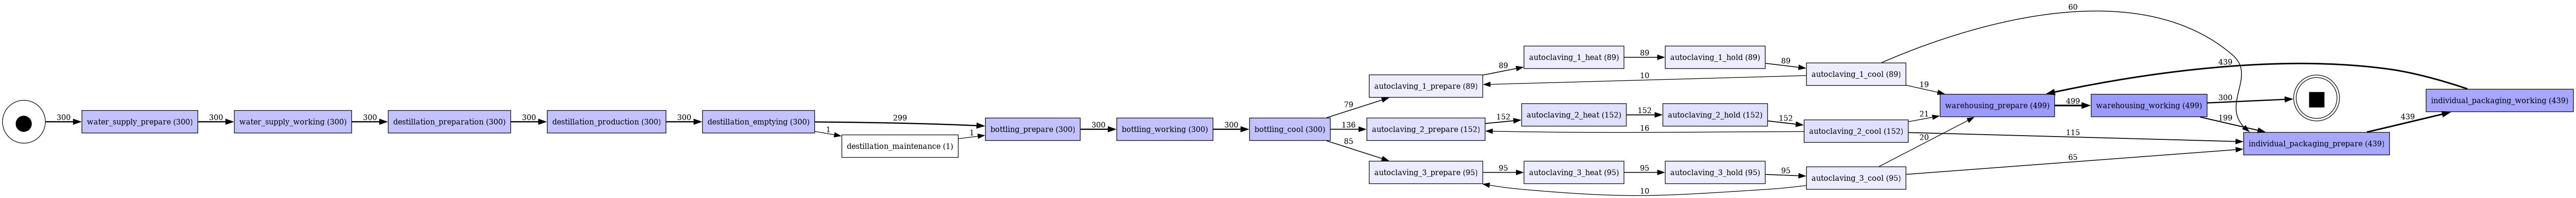

In [ ]:
import tempfile
import pandas as pd
import pm4py
from IPython.display import Image, display
from pm4py.visualization.dfg import visualizer as dfg_vis

# Convert to pm4py event log format
el_pm4py = df_event_log.rename(columns={
    "case_id": "case:concept:name",
    "activity": "concept:name",
    "timestamp_start": "time:timestamp",
})

el_pm4py["time:timestamp"] = pd.to_datetime(el_pm4py["time:timestamp"])

log = pm4py.convert_to_event_log(el_pm4py)

dfg, start_acts, end_acts = pm4py.discover_dfg(log)

gviz = dfg_vis.apply(
    dfg,
    log=log,
    variant=dfg_vis.Variants.FREQUENCY,
    parameters={
        "start_activities": start_acts,
        "end_activities": end_acts
    }
)

with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as f:
    dfg_vis.save(gviz, f.name)
    display(Image(filename=f.name))

### 2b. Station-level DFG  (higher_level_activity)

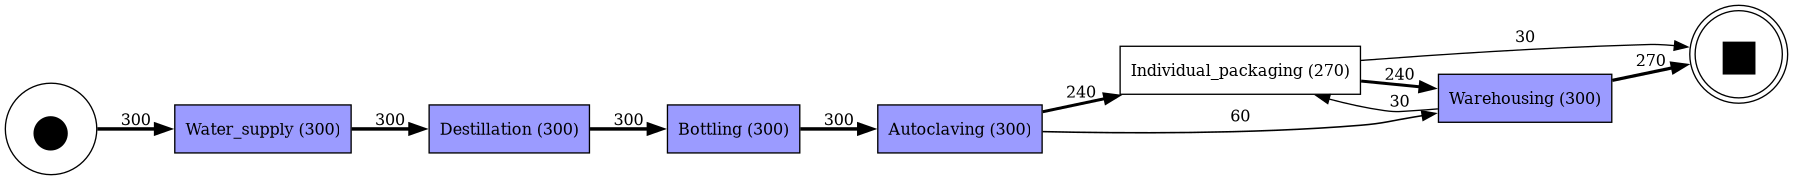

In [ ]:
import tempfile
import pandas as pd
import pm4py
from IPython.display import Image, display
from pm4py.visualization.dfg import visualizer as dfg_vis

# Use first event per (case_id, station) as the station-level trace
station_log = (
    df_event_log
    .sort_values("timestamp_start")
    .groupby(["case_id", "station"], sort=False)
    .first()
    .reset_index()
    .rename(columns={
        "case_id": "case:concept:name",
        "station": "concept:name",
        "timestamp_start": "time:timestamp",
    })
)

station_log["time:timestamp"] = pd.to_datetime(station_log["time:timestamp"])

log_station = pm4py.convert_to_event_log(station_log)

dfg_s, sa_s, ea_s = pm4py.discover_dfg(log_station)

gviz_s = dfg_vis.apply(
    dfg_s,
    log=log_station,
    variant=dfg_vis.Variants.FREQUENCY,
    parameters={
        "start_activities": sa_s,
        "end_activities": ea_s
    }
)

with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as f:
    dfg_vis.save(gviz_s, f.name)
    display(Image(filename=f.name))

## 3. Process model – Inductive Miner (Petri net)

Petri nets discovered with the **Inductive Miner** give you a formal model of the control flow. A green square = source place (start), a red square = sink place (end), rounded boxes = transitions (activities).

### 3a. Activity-level Petri net

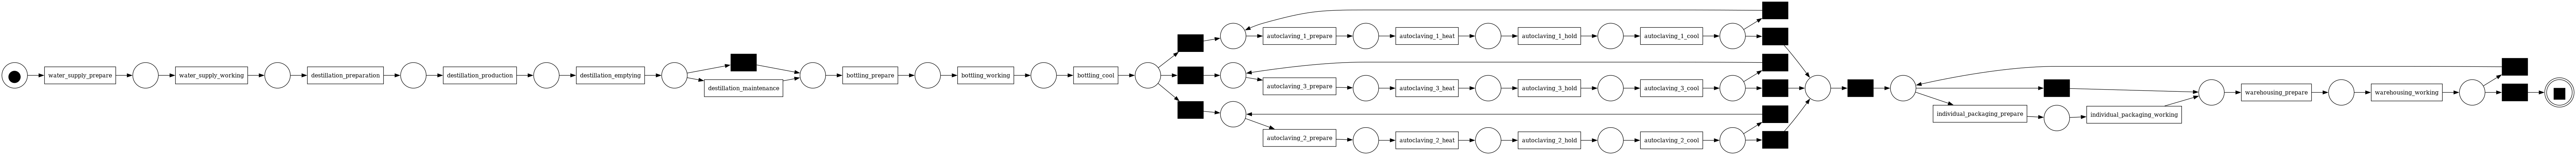

In [ ]:
import tempfile
from IPython.display import Image, display
from pm4py.visualization.petri_net import visualizer as pn_vis

# Discover Petri net from the activity-level log
net_a, im_a, fm_a = pm4py.discover_petri_net_inductive(log)

gviz_pn_a = pn_vis.apply(
    net_a,
    im_a,
    fm_a,
    variant=pn_vis.Variants.FREQUENCY,
    parameters={"log": log}
)

with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as f:
    pn_vis.save(gviz_pn_a, f.name)
    display(Image(filename=f.name))

### 3b. Station-level Petri net

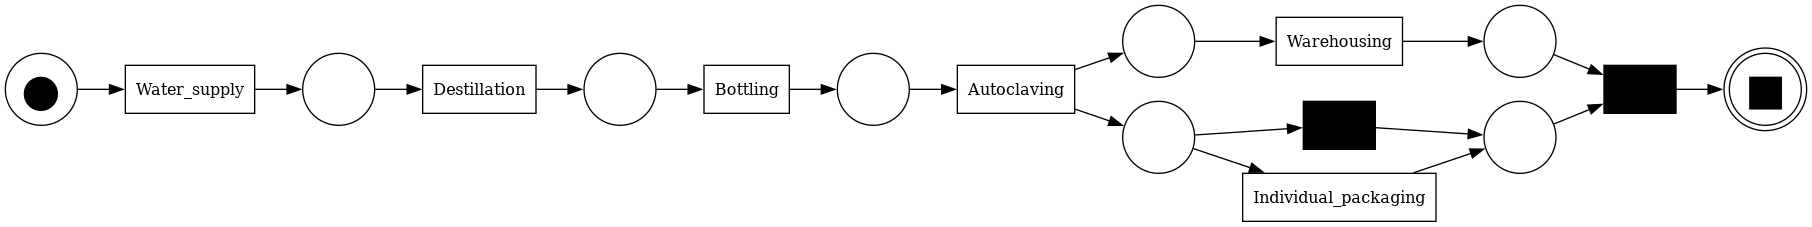

In [ ]:
import tempfile
from IPython.display import Image, display
from pm4py.visualization.petri_net import visualizer as pn_vis

# Discover Petri net from the station-level log
net_s, im_s, fm_s = pm4py.discover_petri_net_inductive(log_station)

gviz_pn_s = pn_vis.apply(
    net_s,
    im_s,
    fm_s,
    variant=pn_vis.Variants.FREQUENCY,
    parameters={"log": log_station}
)

with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as f:
    pn_vis.save(gviz_pn_s, f.name)
    display(Image(filename=f.name))

## 3. Duration distributions per station / activity

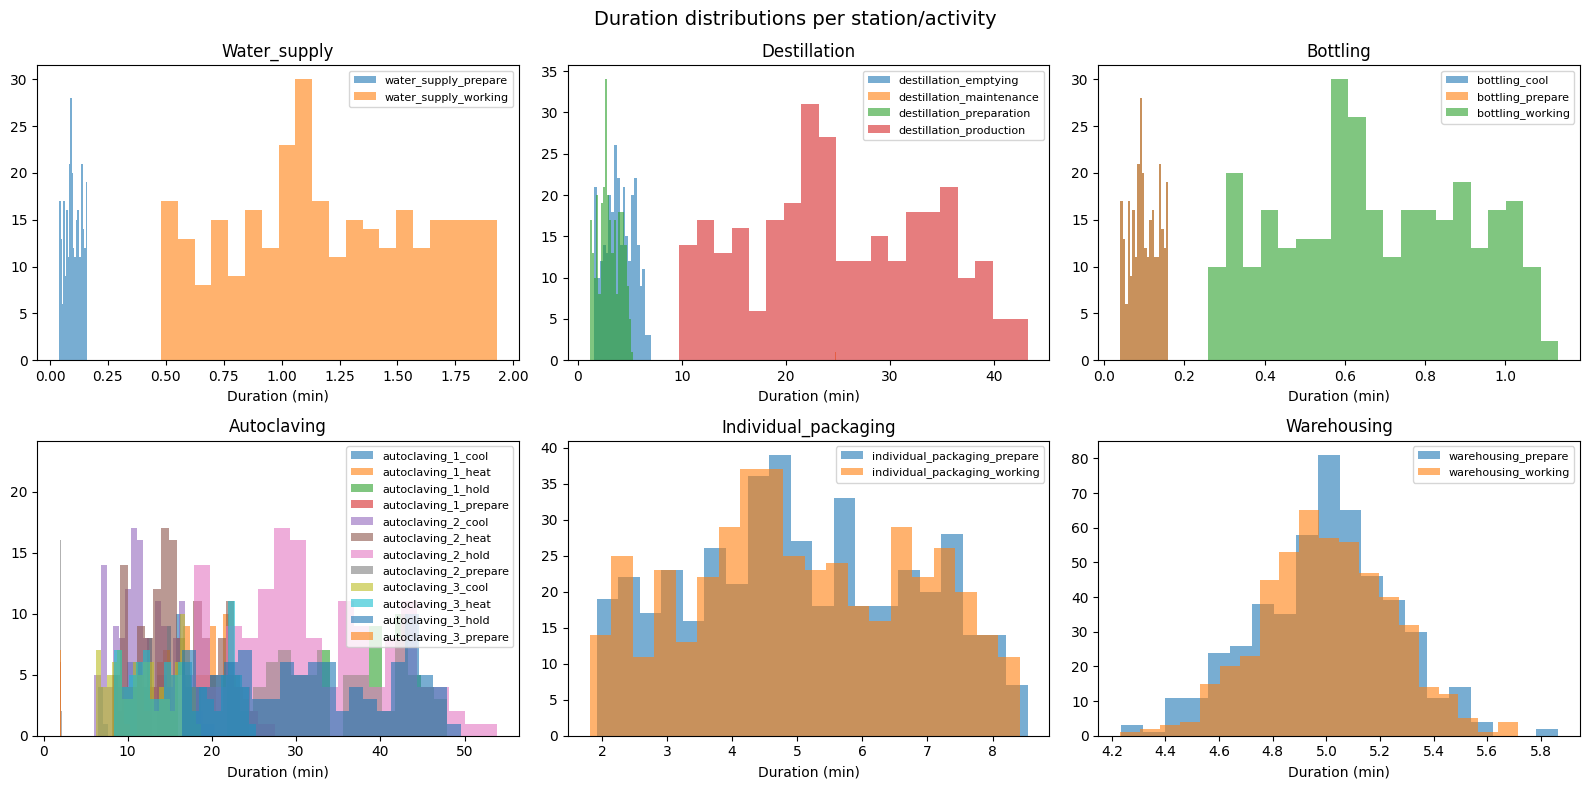

In [ ]:
df_event_log['duration_min'] = (
    (df_event_log['timestamp_end'] - df_event_log['timestamp_start'])
    .dt.total_seconds() / 60
)

stations = df_event_log['station'].unique()
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, station in zip(axes, stations):
    sub = df_event_log[df_event_log['station'] == station]
    for act, grp in sub.groupby('activity'):
        ax.hist(grp['duration_min'], bins=20, alpha=0.6, label=act)
    ax.set_title(station)
    ax.set_xlabel('Duration (min)')
    ax.legend(fontsize=8)

plt.suptitle('Duration distributions per station/activity', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Gantt chart – batch timeline (first 20 batches)

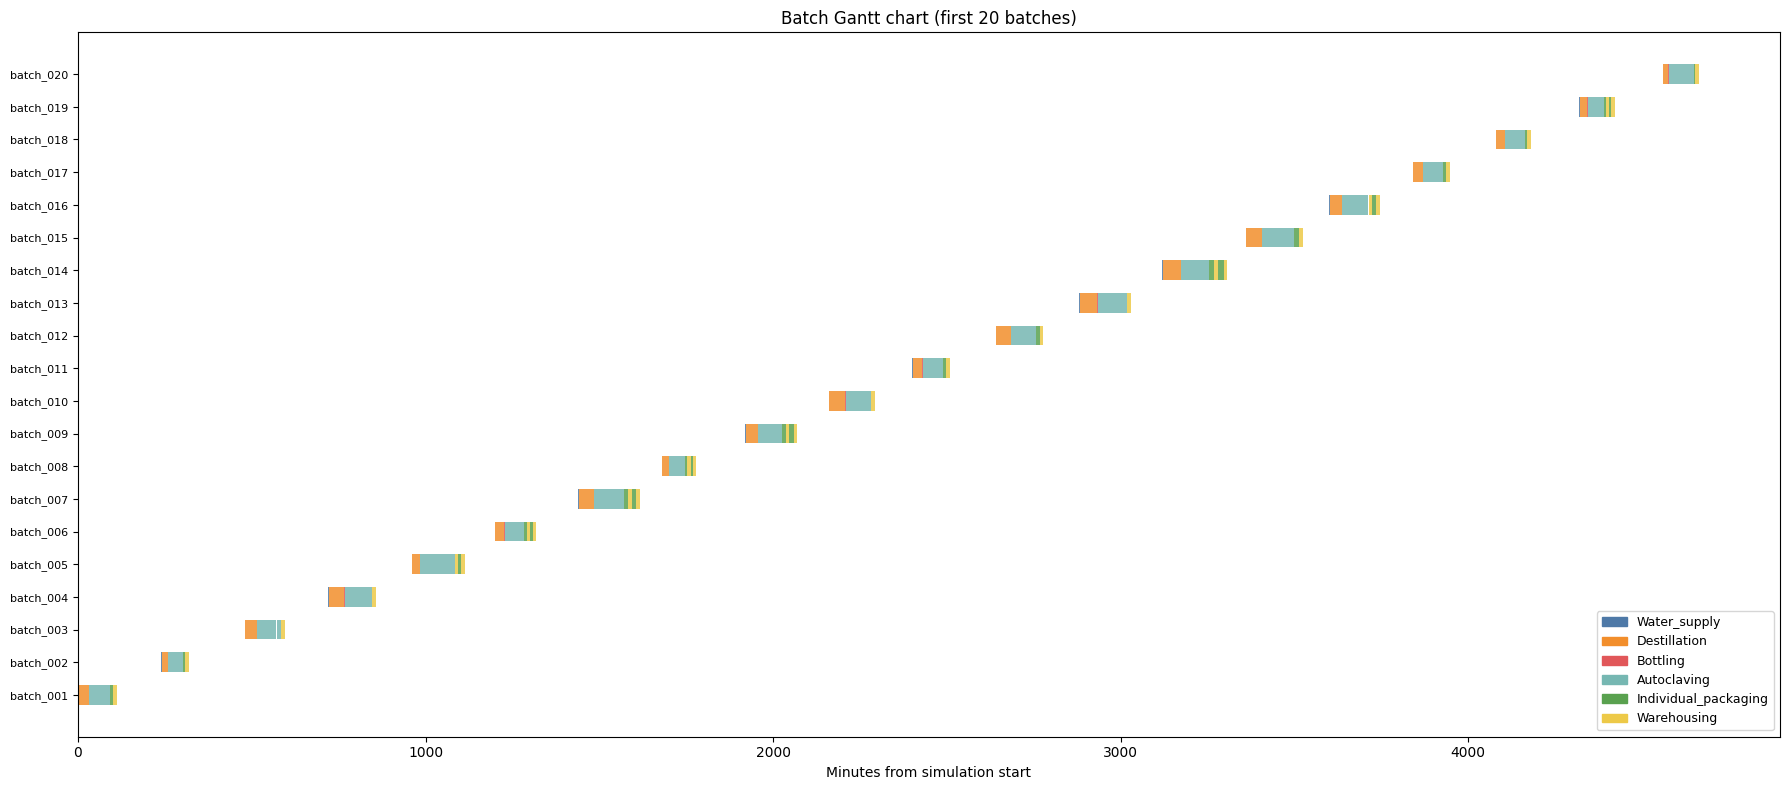

In [ ]:
N_GANTT = 20
batches = df_event_log['case_id'].unique()[:N_GANTT]

STATION_COLORS = {
    'Water_supply':  '#4e79a7',
    'Destillation':  '#f28e2b',
    'Bottling':      '#e15759',
    'Autoclaving':   '#76b7b2',
    'Individual_packaging':     '#59a14f',
    'Warehousing':   '#edc948',
}

fig, ax = plt.subplots(figsize=(18, 8))
t0 = df_event_log['timestamp_start'].min()

for yi, bid in enumerate(batches):
    sub = df_event_log[df_event_log['case_id'] == bid]
    for _, row in sub.iterrows():
        start = (row['timestamp_start'] - t0).total_seconds() / 60
        dur   = (row['timestamp_end']   - row['timestamp_start']).total_seconds() / 60
        color = STATION_COLORS.get(row['station'], 'grey')
        ax.barh(yi, dur, left=start, height=0.6, color=color, alpha=0.85)

ax.set_yticks(range(N_GANTT))
ax.set_yticklabels(batches, fontsize=8)
ax.set_xlabel('Minutes from simulation start')
ax.set_title('Batch Gantt chart (first 20 batches)')
patches = [mpatches.Patch(color=c, label=s) for s, c in STATION_COLORS.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Energy curves – sample batches

Each subplot shows one energy sensor over time, colored by activity.

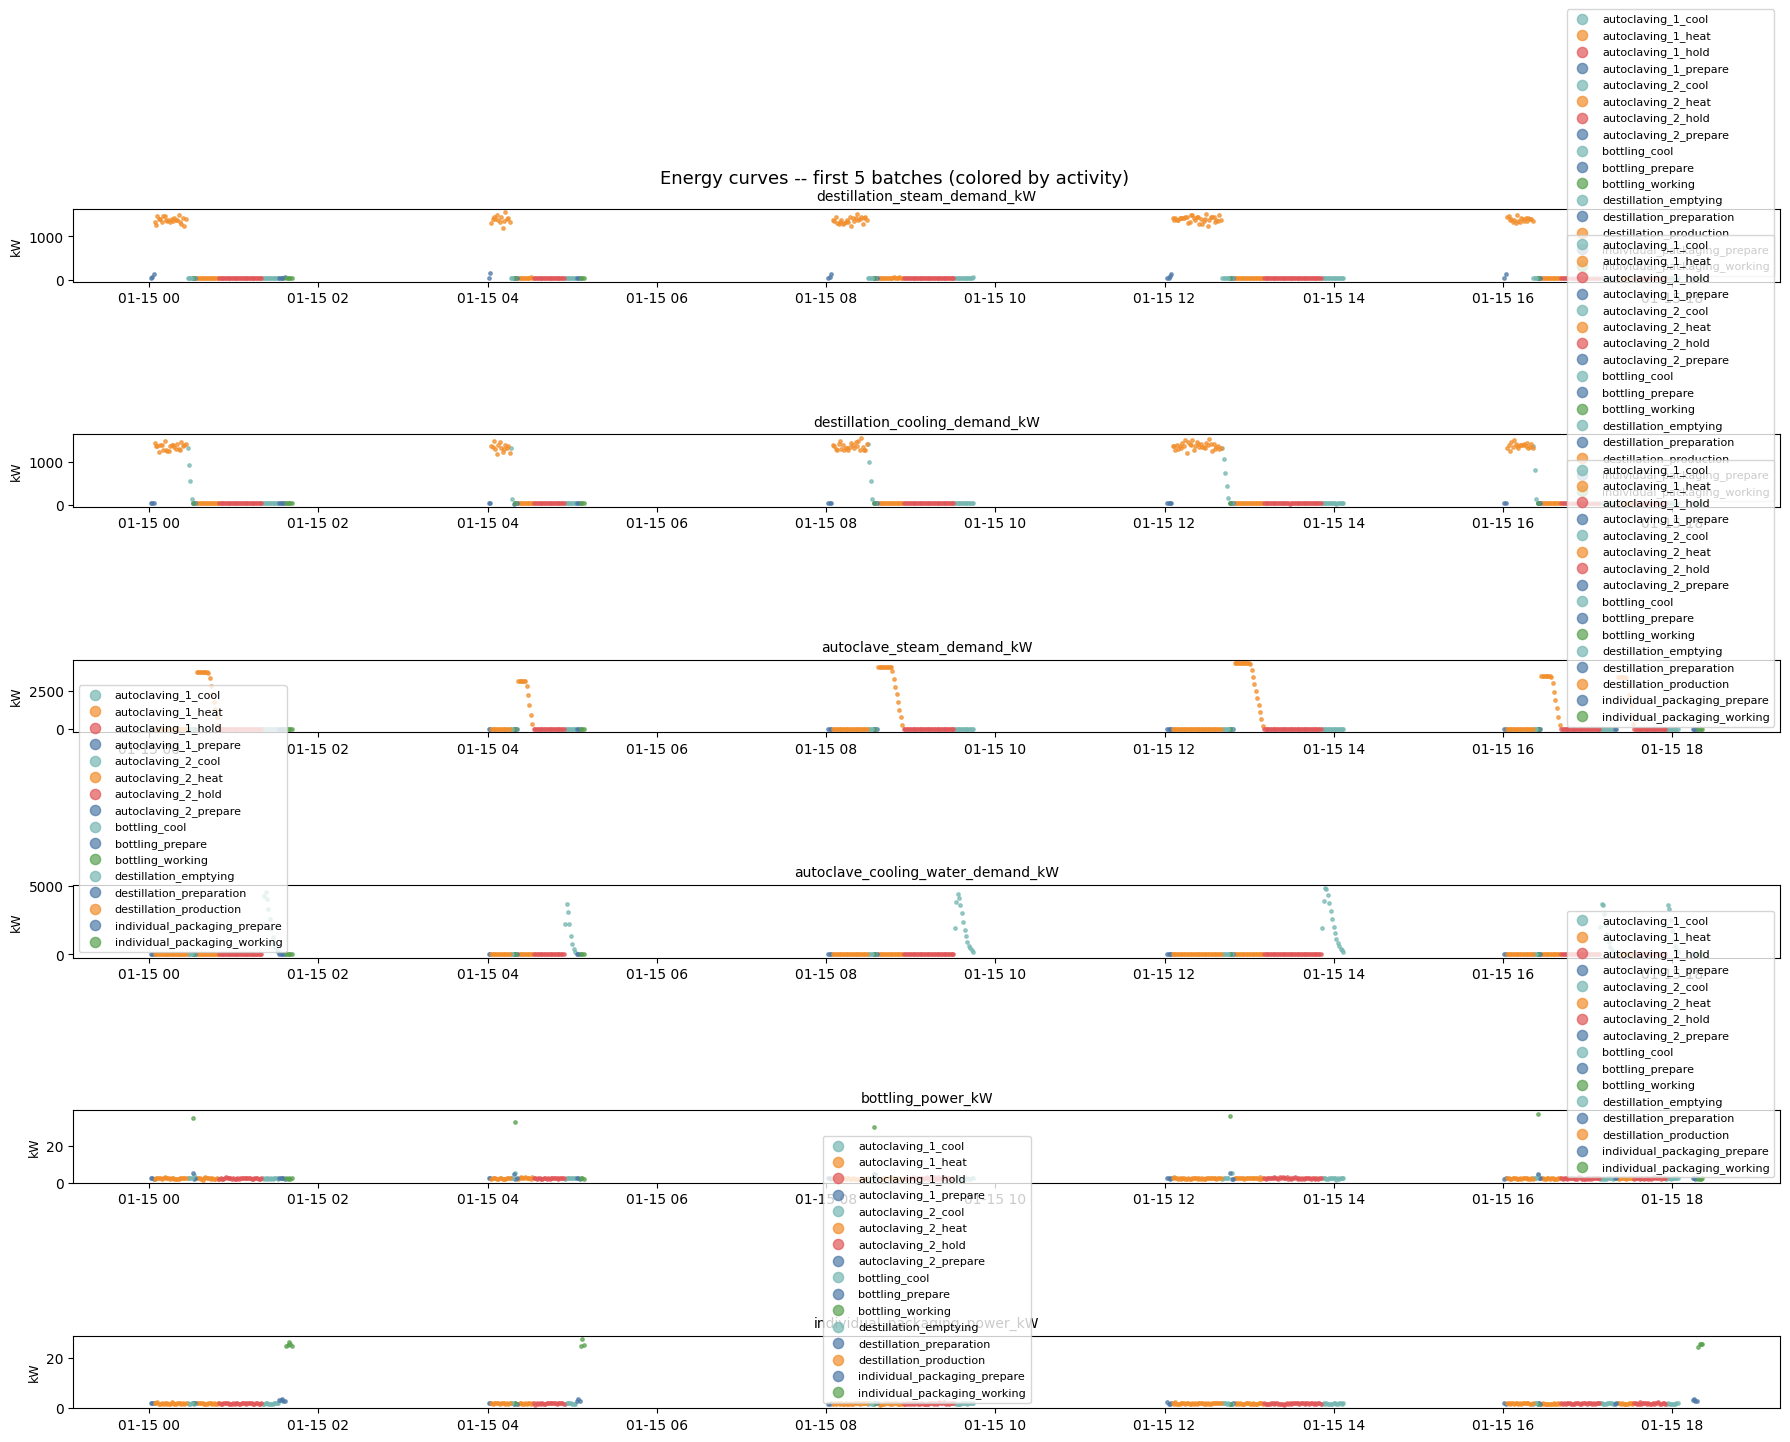

In [ ]:
ENERGY_SENSORS = [
    'destillation_steam_demand_kW_energy_to_model',
    'destillation_cooling_demand_kW_energy_to_model',
    'autoclave_steam_demand_kW_energy_to_model',
    'autoclave_cooling_water_demand_kW_energy_to_model',
    'bottling_power_kW_energy_to_model',
    'individual_packaging_power_kW_energy_to_model',
]

ACTIVITY_COLORS = {
    'prepare':     '#4e79a7',
    'preparation': '#4e79a7',
    'heat':        '#f28e2b',
    'production':  '#f28e2b',
    'hold':        '#e15759',
    'cool':        '#76b7b2',
    'emptying':    '#76b7b2',
    'working':     '#59a14f',
}

# Show first 5 batches for clarity
SAMPLE_BATCHES = df_event_log['case_id'].unique()[:5]
sub_exp = df_expanded[df_expanded['case_id_log'].isin(SAMPLE_BATCHES)].copy()

fig, axes = plt.subplots(len(ENERGY_SENSORS), 1, figsize=(18, 14), sharex=False)

for ax, sensor in zip(axes, ENERGY_SENSORS):
    active = sub_exp[sub_exp[sensor] > 0].copy()
    if active.empty:
        ax.set_title(sensor + ' -- no data')
        continue
    for act, grp in active.groupby('activity_log'):
        # activity_log is now 'resource_actname' (e.g. 'autoclaving_1_heat')
        short = act.split('_')[-1]
        color = ACTIVITY_COLORS.get(short, 'grey')
        ax.scatter(grp['datetime_energy'], grp[sensor],
                   s=6, color=color, alpha=0.7, label=act)
    ax.set_ylabel('kW', fontsize=9)
    ax.set_title(sensor.replace('_energy_to_model', ''), fontsize=10)
    ax.legend(fontsize=8, markerscale=3)

plt.suptitle('Energy curves -- first 5 batches (colored by activity)', fontsize=13)
plt.tight_layout()
plt.show()

## 5b. Autoclave physical profiles – cycle-to-cycle variability

Heat/hold/cool power draw comes from `autoclave_function.sterilization_profile`, called
once per autoclave cycle with randomized physical parameters (steam/cooling flow rates,
wall heat-loss coefficient, sterilization target, thermal mass) — not a fixed shape
stretched in time. Each line below is one real cycle, time-aligned to its own start so
the shapes are comparable. The cooling curve is a logistic ("S-curve") decay: slow
start, a fast mid-cycle drop, slow tail — instead of a plain exponential.

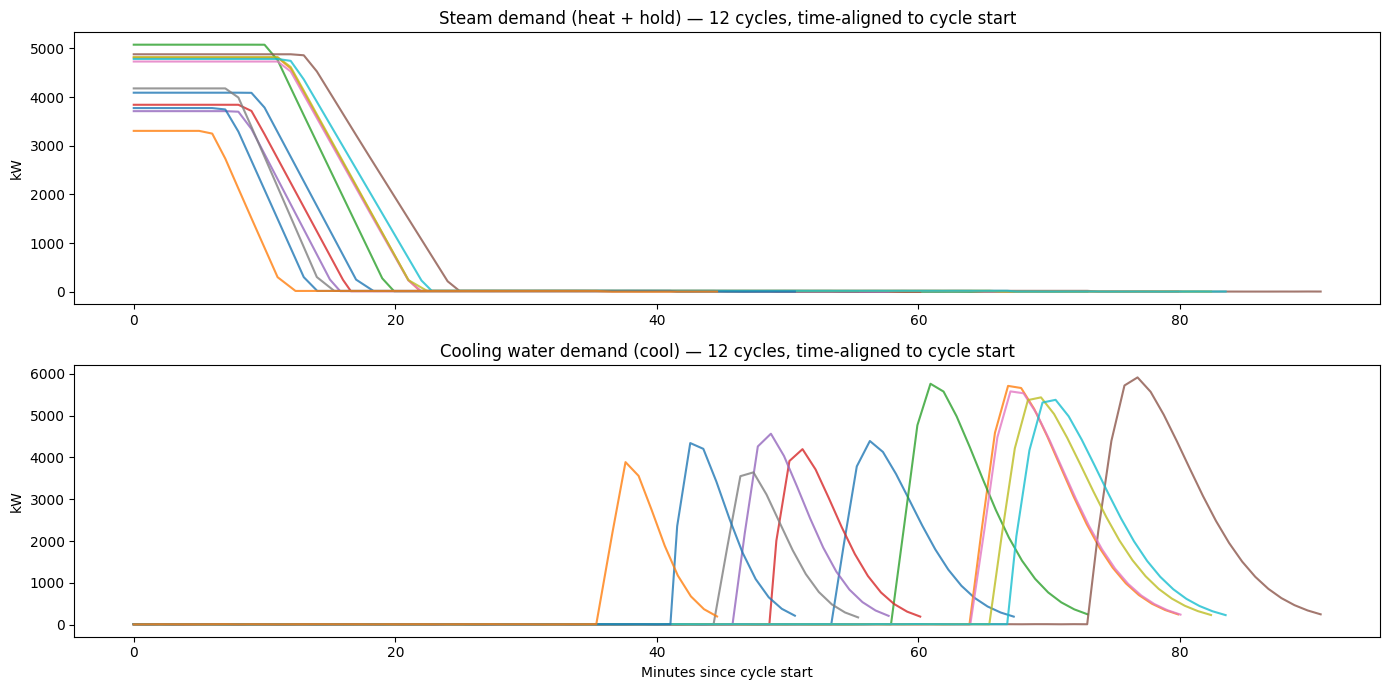

In [ ]:
N_CYCLES_PER_RESOURCE = 3

ac = df_event_log[
    (df_event_log['station'] == 'Autoclaving') &
    (df_event_log['activity'].str.endswith(('_heat', '_hold', '_cool')))
].sort_values('timestamp_start')

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
n_plotted = 0

for resource, grp in ac.groupby('object'):
    heats = grp[grp['activity'].str.endswith('_heat')].reset_index(drop=True)
    step = max(1, len(heats) // N_CYCLES_PER_RESOURCE)
    for i in range(0, len(heats), step):
        cycle_start = heats['timestamp_start'].iloc[i]
        cools = grp[(grp['activity'].str.endswith('_cool')) & (grp['timestamp_start'] >= cycle_start)]
        if cools.empty:
            continue
        cycle_end = cools['timestamp_end'].iloc[0]
        cyc = df_expanded[
            (df_expanded['object_log'] == resource) &
            (df_expanded['datetime_energy'] >= cycle_start) &
            (df_expanded['datetime_energy'] <= cycle_end)
        ].sort_values('datetime_energy')
        if cyc.empty:
            continue
        t_rel = (cyc['datetime_energy'] - cycle_start).dt.total_seconds() / 60
        axes[0].plot(t_rel, cyc['autoclave_steam_demand_kW_energy_to_model'], alpha=0.8)
        axes[1].plot(t_rel, cyc['autoclave_cooling_water_demand_kW_energy_to_model'], alpha=0.8)
        n_plotted += 1

axes[0].set_title(f'Steam demand (heat + hold) — {n_plotted} cycles, time-aligned to cycle start')
axes[0].set_ylabel('kW')
axes[1].set_title(f'Cooling water demand (cool) — {n_plotted} cycles, time-aligned to cycle start')
axes[1].set_ylabel('kW')
axes[1].set_xlabel('Minutes since cycle start')
plt.tight_layout()
plt.show()

## 5c. Destillation physical profiles – cycle-to-cycle variability

Steam demand (preparation + production) and cooling demand (production + emptying)
come from `destilation_function.DistillationEnergyDemand`: production plateaus at the
physical heating/cooling demand (±5% noise), preparation ramps steam up to 10% of that
level, and emptying ramps cooling down to 10% before the vessel goes idle. Each line
below is one real Destillation visit, time-aligned to the start of preparation.

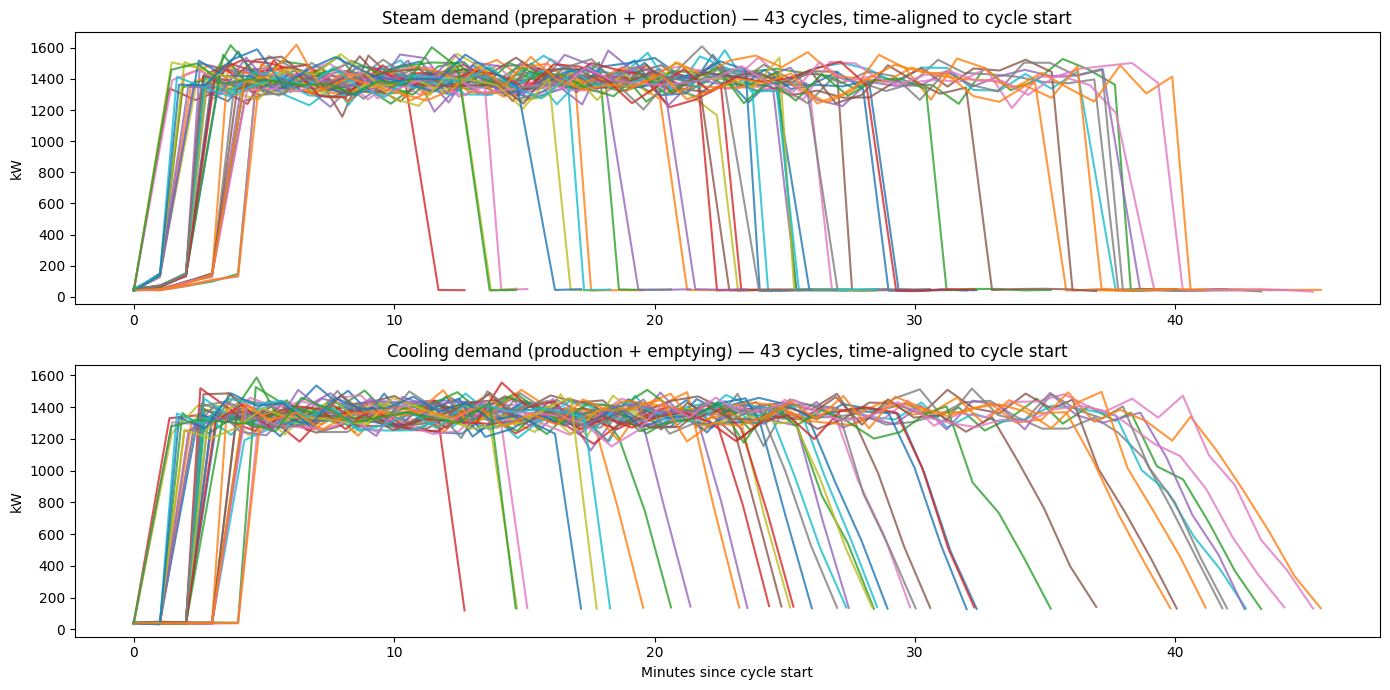

In [ ]:
N_DESTILLATION_CYCLES = 40

dest_ev = df_event_log[
    (df_event_log['station'] == 'Destillation') &
    (df_event_log['activity'].str.endswith(('_preparation', '_production', '_emptying')))
].sort_values('timestamp_start')

preps = dest_ev[dest_ev['activity'].str.endswith('_preparation')].reset_index(drop=True)
step = max(1, len(preps) // N_DESTILLATION_CYCLES)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
n_plotted = 0

for i in range(0, len(preps), step):
    cycle_start = preps['timestamp_start'].iloc[i]
    emptyings = dest_ev[
        (dest_ev['activity'].str.endswith('_emptying')) & (dest_ev['timestamp_start'] >= cycle_start)
    ]
    if emptyings.empty:
        continue
    cycle_end = emptyings['timestamp_end'].iloc[0]
    cyc = df_expanded[
        (df_expanded['datetime_energy'] >= cycle_start) &
        (df_expanded['datetime_energy'] <= cycle_end) &
        (df_expanded['station_log'] == 'Destillation')
    ].sort_values('datetime_energy')
    if cyc.empty:
        continue
    t_rel = (cyc['datetime_energy'] - cycle_start).dt.total_seconds() / 60
    axes[0].plot(t_rel, cyc['destillation_steam_demand_kW_energy_to_model'], alpha=0.8)
    axes[1].plot(t_rel, cyc['destillation_cooling_demand_kW_energy_to_model'], alpha=0.8)
    n_plotted += 1

axes[0].set_title(f'Steam demand (preparation + production) — {n_plotted} cycles, time-aligned to cycle start')
axes[0].set_ylabel('kW')
axes[1].set_title(f'Cooling demand (production + emptying) — {n_plotted} cycles, time-aligned to cycle start')
axes[1].set_ylabel('kW')
axes[1].set_xlabel('Minutes since cycle start')
plt.tight_layout()
plt.show()

## 6. Weather vs. energy – verifying physical relationships

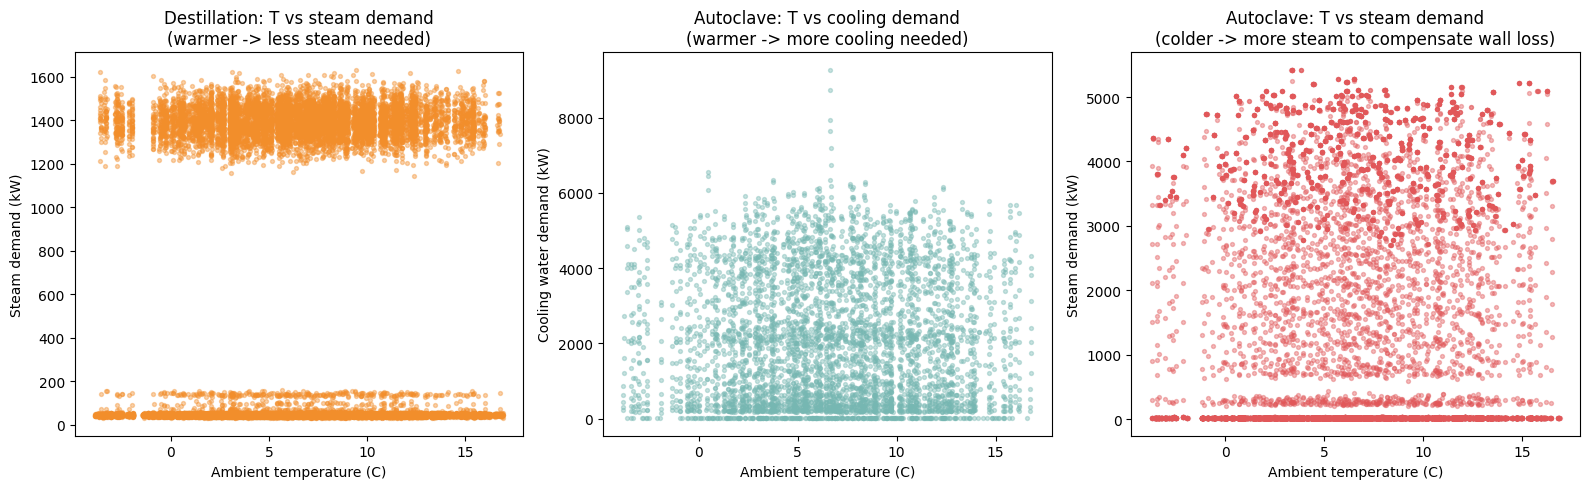

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 6a. Temperature vs. distillation steam demand
dest = df_expanded[df_expanded['destillation_steam_demand_kW_energy_to_model'] > 0]
axes[0].scatter(dest['ef_temperature_2m_energy'],
                dest['destillation_steam_demand_kW_energy_to_model'],
                s=8, alpha=0.4, color='#f28e2b')
axes[0].set_xlabel('Ambient temperature (C)')
axes[0].set_ylabel('Steam demand (kW)')
axes[0].set_title('Destillation: T vs steam demand\n(warmer -> less steam needed)')

# 6b. Temperature vs. autoclave cooling water demand (cool phase only)
cool = df_expanded[
    (df_expanded['autoclave_cooling_water_demand_kW_energy_to_model'] > 0) &
    (df_expanded['activity_log'].str.endswith('_cool'))
]
axes[1].scatter(cool['ef_temperature_2m_energy'],
                cool['autoclave_cooling_water_demand_kW_energy_to_model'],
                s=8, alpha=0.4, color='#76b7b2')
axes[1].set_xlabel('Ambient temperature (C)')
axes[1].set_ylabel('Cooling water demand (kW)')
axes[1].set_title('Autoclave: T vs cooling demand\n(warmer -> more cooling needed)')

# 6c. Temperature vs. autoclave steam demand (heat + hold)
steam = df_expanded[
    (df_expanded['autoclave_steam_demand_kW_energy_to_model'] > 0) &
    (df_expanded['activity_log'].str.endswith(('_heat', '_hold')))
]
axes[2].scatter(steam['ef_temperature_2m_energy'],
                steam['autoclave_steam_demand_kW_energy_to_model'],
                s=8, alpha=0.4, color='#e15759')
axes[2].set_xlabel('Ambient temperature (C)')
axes[2].set_ylabel('Steam demand (kW)')
axes[2].set_title('Autoclave: T vs steam demand\n(colder -> more steam to compensate wall loss)')

plt.tight_layout()
plt.show()

## 7. Weather time series over the simulation period

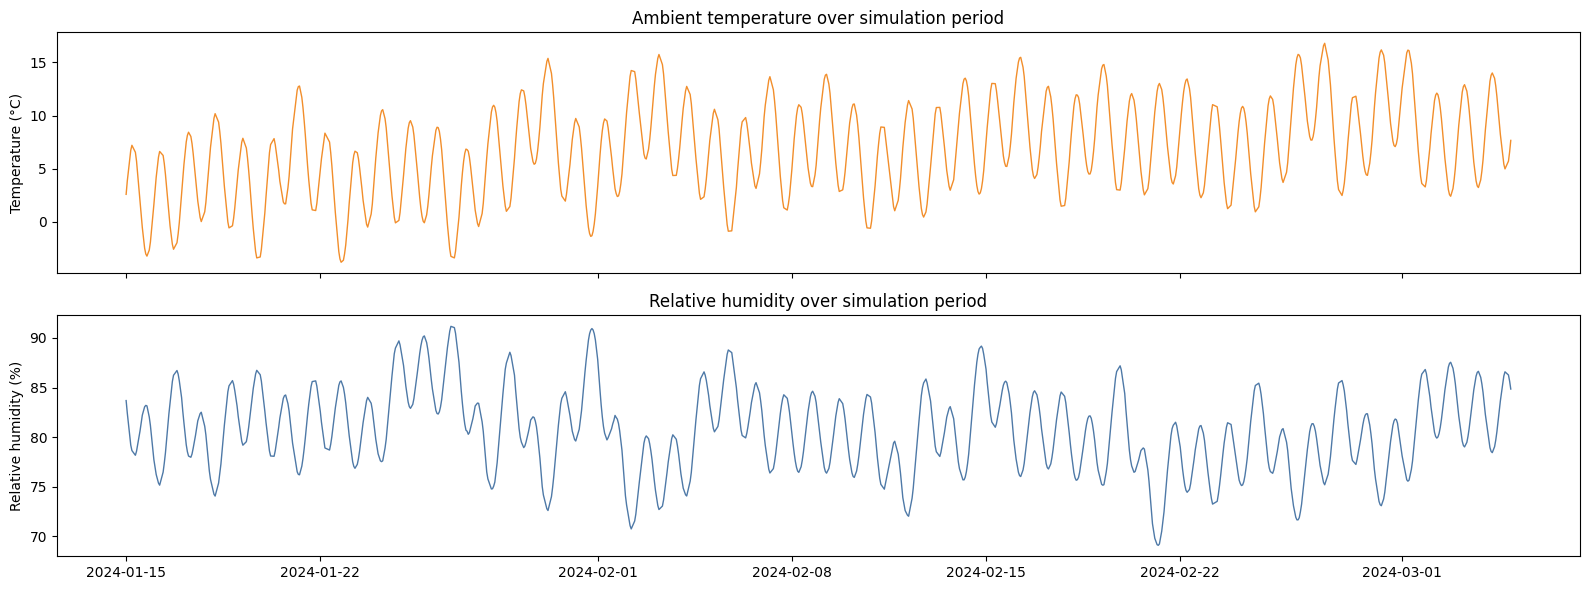

In [ ]:
weather = (
    df_expanded
    .set_index('datetime_energy')[['ef_temperature_2m_energy', 'ef_relative_humidity_2m_energy']]
    .resample('1h').mean()
    .dropna()
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

ax1.plot(weather.index, weather['ef_temperature_2m_energy'], color='#f28e2b', lw=1)
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Ambient temperature over simulation period')

ax2.plot(weather.index, weather['ef_relative_humidity_2m_energy'], color='#4e79a7', lw=1)
ax2.set_ylabel('Relative humidity (%)')
ax2.set_title('Relative humidity over simulation period')

plt.tight_layout()
plt.show()

## 8. Autoclave load – how many autoclave resources run in parallel

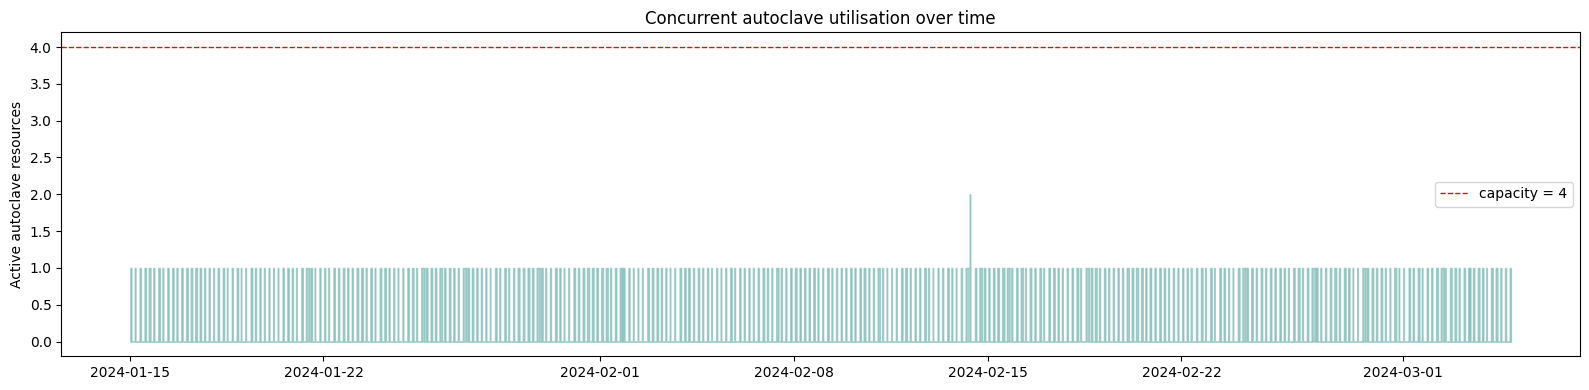

In [ ]:
ac_events = df_event_log[df_event_log['station'] == 'Autoclaving'].copy()

# Build 1-minute timeline of concurrent autoclave usage
t_min = ac_events['timestamp_start'].min().floor('min')
t_max = ac_events['timestamp_end'].max().ceil('min')
timeline = pd.date_range(t_min, t_max, freq='min')

concurrent = np.zeros(len(timeline))
for _, row in ac_events.iterrows():
    mask = (timeline >= row['timestamp_start']) & (timeline < row['timestamp_end'])
    concurrent[mask] += 1

fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(timeline, concurrent, step='pre', alpha=0.6, color='#76b7b2')
ax.set_ylabel('Active autoclave resources')
ax.set_title('Concurrent autoclave utilisation over time')
ax.axhline(4, color='red', linestyle='--', lw=1, label='capacity = 4')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Expanded dataset overview

In [ ]:
df_expanded.head(5)

,datetime_energy,ef_temperature_2m_energy,ef_relative_humidity_2m_energy,destillation_steam_demand_kW_energy_to_model,destillation_cooling_demand_kW_energy_to_model,autoclave_steam_demand_kW_energy_to_model,autoclave_cooling_water_demand_kW_energy_to_model,bottling_power_kW_energy_to_model,individual_packaging_power_kW_energy_to_model,timestamp_start_log,timestamp_end_log,activity_log,higher_level_activity_log,station_log,object_type_log,object_log,case_id_log,object_attributes_log
0,2024-01-15 00:01:12.977309,2.604850,83.810208,50.783851,40.358068,6.196052,13.363755,2.706061,1.904212,2024-01-15 00:01:12.977309,2024-01-15 00:03:48.915022,destillation_preparation,sterilization_process,Destillation,sterilization_line,destillation,batch_001,"{'idle_min': 1.2, 'recipe': 'standard', 'volum..."
1,2024-01-15 00:02:12.977309,2.604082,83.805943,72.154780,36.433943,6.225701,11.385649,2.706809,1.838026,2024-01-15 00:01:12.977309,2024-01-15 00:03:48.915022,destillation_preparation,sterilization_process,Destillation,sterilization_line,destillation,batch_001,"{'idle_min': 1.2, 'recipe': 'standard', 'volum..."
2,2024-01-15 00:03:12.977309,2.603314,83.801678,135.490355,40.937038,6.425508,12.213024,2.304358,1.847219,2024-01-15 00:01:12.977309,2024-01-15 00:03:48.915022,destillation_preparation,sterilization_process,Destillation,sterilization_line,destillation,batch_001,"{'idle_min': 1.2, 'recipe': 'standard', 'volum..."
3,2024-01-15 00:03:49.915022,2.603314,83.801678,1332.351884,1422.053567,6.433221,10.910091,2.375557,1.909028,2024-01-15 00:03:49.915022,2024-01-15 00:27:08.781001,destillation_production,sterilization_process,Destillation,sterilization_line,destillation,batch_001,"{'idle_min': 1.2, 'recipe': 'standard', 'volum..."
4,2024-01-15 00:04:49.915022,2.602546,83.797414,1256.759598,1360.268771,5.496330,11.493869,2.860835,1.788393,2024-01-15 00:03:49.915022,2024-01-15 00:27:08.781001,destillation_production,sterilization_process,Destillation,sterilization_line,destillation,batch_001,"{'idle_min': 1.2, 'recipe': 'standard', 'volum..."


In [ ]:
# Summary stats for energy sensors
sensors = [
    'destillation_steam_demand_kW_energy_to_model',
    'destillation_cooling_demand_kW_energy_to_model',
    'autoclave_steam_demand_kW_energy_to_model',
    'autoclave_cooling_water_demand_kW_energy_to_model',
    'bottling_power_kW_energy_to_model',
    'individual_packaging_power_kW_energy_to_model',
]
# Only non-zero rows per sensor
summary = {}
for s in sensors:
    d = df_expanded[df_expanded[s] > 0][s]
    summary[s] = {'n_rows': len(d), 'mean': d.mean(), 'std': d.std(),
                  'min': d.min(), 'max': d.max()}
pd.DataFrame(summary).T.round(2)

,n_rows,mean,std,min,max
destillation_steam_demand_kW_energy_to_model,36268.0,328.82,550.20,29.68,1633.03
destillation_cooling_demand_kW_energy_to_model,36268.0,338.71,545.13,26.49,1596.76
autoclave_steam_demand_kW_energy_to_model,36268.0,500.18,1276.15,3.46,5426.00
autoclave_cooling_water_demand_kW_energy_to_model,36268.0,266.46,902.66,6.76,9275.10
bottling_power_kW_energy_to_model,36268.0,2.81,2.97,1.51,40.40
individual_packaging_power_kW_energy_to_model,36268.0,3.29,5.57,1.08,30.60
